In [11]:
import pandas as pd
from glob import glob
import re
import numpy as np
def extract_date(filename):
    match = re.search(r'_(\d{8})', filename)
    return int(match.group(1)) if match else 0

depth_files = sorted(glob('../../data/raw/depth20_1000ms/*.txt'), key=extract_date)
aggtrade_files = sorted(glob('../../data/raw/aggTrade/*.txt'), key=extract_date)
depth20_df = pd.concat([pd.read_csv(f) for f in depth_files], ignore_index=True)
aggtrade_df = pd.concat([pd.read_csv(f) for f in aggtrade_files], ignore_index=True)


In [12]:
depth20_df.head()

,Time,BidPriceL20,BidQtyL20,BidPriceL19,BidQtyL19,BidPriceL18,BidQtyL18,BidPriceL17,BidQtyL17,BidPriceL16,...,AskPriceL16,AskQtyL16,AskPriceL17,AskQtyL17,AskPriceL18,AskQtyL18,AskPriceL19,AskQtyL19,AskPriceL20,AskQtyL20
0,2025-03-14 00:00:02.292522546 +0530 IST,579.20,0.621,579.24,0.015,579.25,0.009,579.26,0.013,579.27,...,579.67,1.151,579.68,0.043,579.69,1.258,579.70,0.911,579.71,2.025
1,2025-03-14 00:00:03.292828523 +0530 IST,579.08,2.612,579.09,8.606,579.10,3.453,579.11,3.825,579.12,...,579.59,0.971,579.60,5.071,579.61,4.894,579.62,1.017,579.63,0.048
2,2025-03-14 00:00:04.292889586 +0530 IST,579.14,1.948,579.15,3.957,579.18,1.681,579.19,3.465,579.20,...,579.62,1.017,579.63,0.048,579.64,9.720,579.65,2.025,579.66,0.365
3,2025-03-14 00:00:05.292551566 +0530 IST,579.07,0.013,579.08,0.013,579.09,8.606,579.10,3.453,579.11,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,7.213
4,2025-03-14 00:00:06.292725093 +0530 IST,579.11,9.143,579.12,6.361,579.13,5.837,579.14,2.816,579.15,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,10.469


In [13]:
# Vectorized timezone parsing: Strip ' IST' suffix
depth20_df['Time'] = depth20_df['Time'].str[:-4]
aggtrade_df['Time'] = aggtrade_df['Time'].str[:-4]

In [14]:
# Convert to datetime and align to UTC preserving offset context
depth20_df['Time'] = pd.to_datetime(depth20_df['Time'], utc=True)
aggtrade_df['Time'] = pd.to_datetime(aggtrade_df['Time'], utc=True)

In [15]:
depth20_df['Time']

0        2025-03-13 18:30:02.292522546+00:00
1        2025-03-13 18:30:03.292828523+00:00
2        2025-03-13 18:30:04.292889586+00:00
3        2025-03-13 18:30:05.292551566+00:00
4        2025-03-13 18:30:06.292725093+00:00
                         ...                
338514   2025-03-17 18:30:04.292194568+00:00
338515   2025-03-17 18:30:05.292363895+00:00
338516   2025-03-17 18:30:06.292254740+00:00
338517   2025-03-17 18:30:07.292648033+00:00
338518   2025-03-17 18:30:08.292464563+00:00
Name: Time, Length: 338519, dtype: datetime64[ns, UTC]

In [16]:
depth20_df.set_index('Time', inplace=True)
aggtrade_df.set_index('Time', inplace=True)

In [17]:
# Sort indices to prepare for causal merge_asof alignment
depth20_df = depth20_df.sort_index()
aggtrade_df = aggtrade_df.sort_index()

if 'NumTrades' not in aggtrade_df.columns:
    aggtrade_df['NumTrades'] = 1

# Merge raw datasets causally using backward matching to align the order book
# state immediately preceding each trade event, preventing look-ahead bias
merged_raw = pd.merge_asof(
    aggtrade_df,
    depth20_df,
    left_index=True,
    right_index=True,
    direction='backward'
)

In [18]:
# Construct aggregation dictionary to aggregate trade volume/count and order book states
agg_dict = {
    'Price': 'last',
    'Quantity': 'sum',
    'NumTrades': 'sum',
    'IsMarketMaker': 'last'
}
for col in depth20_df.columns:
    agg_dict[col] = 'last'

# Resample causal merged data to 1-second intervals
merged_df = merged_raw.resample('1s').agg(agg_dict)

# Forward-fill prices and book states
state_cols = ['Price', 'IsMarketMaker'] + list(depth20_df.columns)
merged_df[state_cols] = merged_df[state_cols].ffill()

# Fill missing quantities and trades with 0
merged_df['Quantity'] = merged_df['Quantity'].fillna(0.0)
merged_df['NumTrades'] = merged_df['NumTrades'].fillna(0.0)

# Reset index to Time for downstream consistency
merged_df = merged_df.reset_index()

In [19]:
# Preview the resampled order book columns from the merged dataframe
merged_df[['Time', 'BidPriceL1', 'BidQtyL1', 'AskPriceL1', 'AskQtyL1']].head()

,Time,BidPriceL1,BidQtyL1,AskPriceL1,AskQtyL1
0,2025-03-13 18:30:02+00:00,579.44,0.961,579.52,0.961
1,2025-03-13 18:30:03+00:00,579.36,0.961,579.44,0.961
2,2025-03-13 18:30:04+00:00,579.37,0.789,579.45,0.961
3,2025-03-13 18:30:05+00:00,579.31,0.961,579.37,0.961
4,2025-03-13 18:30:06+00:00,579.31,0.961,579.37,0.961


In [20]:
# Preview the resampled trade activity columns from the merged dataframe
merged_df[['Time', 'Price', 'Quantity', 'NumTrades']].head()

,Time,Price,Quantity,NumTrades
0,2025-03-13 18:30:02+00:00,579.38,0.613,3
1,2025-03-13 18:30:03+00:00,579.30,12.021,6
2,2025-03-13 18:30:04+00:00,579.37,2.515,2
3,2025-03-13 18:30:05+00:00,579.30,1.726,1
4,2025-03-13 18:30:06+00:00,579.30,0.000,0


In [21]:
# Causal raw merging and resampling are already completed in the previous step
print('Total resampled records:', len(merged_df))

Total resampled records: 345597


In [22]:
merged_df.head(5)

,Time,Price,Quantity,NumTrades,IsMarketMaker,BidPriceL20,BidQtyL20,BidPriceL19,BidQtyL19,BidPriceL18,...,AskPriceL16,AskQtyL16,AskPriceL17,AskQtyL17,AskPriceL18,AskQtyL18,AskPriceL19,AskQtyL19,AskPriceL20,AskQtyL20
0,2025-03-13 18:30:02+00:00,579.38,0.613,3,1.0,579.20,0.621,579.24,0.015,579.25,...,579.67,1.151,579.68,0.043,579.69,1.258,579.70,0.911,579.71,2.025
1,2025-03-13 18:30:03+00:00,579.30,12.021,6,1.0,579.08,2.612,579.09,8.606,579.10,...,579.59,0.971,579.60,5.071,579.61,4.894,579.62,1.017,579.63,0.048
2,2025-03-13 18:30:04+00:00,579.37,2.515,2,1.0,579.14,1.948,579.15,3.957,579.18,...,579.62,1.017,579.63,0.048,579.64,9.720,579.65,2.025,579.66,0.365
3,2025-03-13 18:30:05+00:00,579.30,1.726,1,1.0,579.07,0.013,579.08,0.013,579.09,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,7.213
4,2025-03-13 18:30:06+00:00,579.30,0.000,0,1.0,579.07,0.013,579.08,0.013,579.09,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,7.213


In [23]:
features = merged_df.copy()

In [24]:
features.head(5)

,Time,Price,Quantity,NumTrades,IsMarketMaker,BidPriceL20,BidQtyL20,BidPriceL19,BidQtyL19,BidPriceL18,...,AskPriceL16,AskQtyL16,AskPriceL17,AskQtyL17,AskPriceL18,AskQtyL18,AskPriceL19,AskQtyL19,AskPriceL20,AskQtyL20
0,2025-03-13 18:30:02+00:00,579.38,0.613,3,1.0,579.20,0.621,579.24,0.015,579.25,...,579.67,1.151,579.68,0.043,579.69,1.258,579.70,0.911,579.71,2.025
1,2025-03-13 18:30:03+00:00,579.30,12.021,6,1.0,579.08,2.612,579.09,8.606,579.10,...,579.59,0.971,579.60,5.071,579.61,4.894,579.62,1.017,579.63,0.048
2,2025-03-13 18:30:04+00:00,579.37,2.515,2,1.0,579.14,1.948,579.15,3.957,579.18,...,579.62,1.017,579.63,0.048,579.64,9.720,579.65,2.025,579.66,0.365
3,2025-03-13 18:30:05+00:00,579.30,1.726,1,1.0,579.07,0.013,579.08,0.013,579.09,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,7.213
4,2025-03-13 18:30:06+00:00,579.30,0.000,0,1.0,579.07,0.013,579.08,0.013,579.09,...,579.56,0.024,579.57,1.926,579.58,2.127,579.59,0.279,579.60,7.213


In [25]:
features['IsMarketMaker']

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
345592    0.0
345593    0.0
345594    0.0
345595    0.0
345596    0.0
Name: IsMarketMaker, Length: 345597, dtype: float64

In [27]:
features['price_var'] = features['Price'].rolling(window=5).var()
features['time_diff'] = features['Time'].diff().dt.total_seconds()
features['avg_time_diff'] = features['time_diff'].rolling(window=5).mean()
features['value_per_second'] = features['Price'] * features['Quantity']

features['log_return'] = np.log(features['Price'] / features['Price'].shift(1))
features['volatility_10s'] = features['log_return'].rolling(window=10).std()
features['volatility_30s'] = features['log_return'].rolling(window=30).std()

# Prevent division by zero during periods with zero trade volume
quantity_sum_10s = features['Quantity'].rolling(window=10).sum()
features['vwap_10s'] = (features['Price'] * features['Quantity']).rolling(window=10).sum() / quantity_sum_10s
features['vwap_10s'] = features['vwap_10s'].fillna(features['Price'])
quantity_sum_30s = features['Quantity'].rolling(window=30).sum()
features['vwap_30s'] = (features['Price'] * features['Quantity']).rolling(window=30).sum() / quantity_sum_30s
features['vwap_30s'] = features['vwap_30s'].fillna(features['Price'])

features['vwap_10s_shift'] = features['vwap_10s'].diff()
features['vwap_30s_shift'] = features['vwap_30s'].diff()

def compute_obi(df, levels):
    bid_cols = [f'BidQtyL{i}' for i in range(1, levels + 1)]
    ask_cols = [f'AskQtyL{i}' for i in range(1, levels + 1)]

    bid_sum = df[bid_cols].sum(axis=1)
    ask_sum = df[ask_cols].sum(axis=1)

    obi = (bid_sum - ask_sum) / (bid_sum + ask_sum + 1e-9)
    return obi

features['obi_5'] = compute_obi(features, 5)
features['obi_10'] = compute_obi(features, 10)
features['obi_20'] = compute_obi(features, 20)

# Vectorized weighted OBI to give higher importance to price levels close to spread
def compute_weighted_obi(df, levels):
    weights = 1.0 / np.arange(1, levels + 1)
    bid_cols = [f'BidQtyL{i}' for i in range(1, levels + 1)]
    ask_cols = [f'AskQtyL{i}' for i in range(1, levels + 1)]
    weighted_bid = df[bid_cols].dot(weights)
    weighted_ask = df[ask_cols].dot(weights)
    return (weighted_bid - weighted_ask) / (weighted_bid + weighted_ask + 1e-9)

features['weighted_obi_5'] = compute_weighted_obi(features, 5)
features['weighted_obi_10'] = compute_weighted_obi(features, 10)
features['weighted_obi_20'] = compute_weighted_obi(features, 20)

# Bid-Ask Spread and Micro-Price
features['bid_ask_spread'] = features['AskPriceL1'] - features['BidPriceL1']
features['micro_price'] = (features['BidPriceL1'] * features['AskQtyL1'] + features['AskPriceL1'] * features['BidQtyL1']) / (features['BidQtyL1'] + features['AskQtyL1'] + 1e-9)

features['IsMarketMaker'] = features['IsMarketMaker'].astype(bool)
buy_mask = ~features['IsMarketMaker']
sell_mask = features['IsMarketMaker']
features['avg_buy_price'] = features['Price'].where(buy_mask).rolling(window=1).mean()
features['avg_sell_price'] = features['Price'].where(sell_mask).rolling(window=1).mean()
features['buy_volume'] = features['Quantity'].where(buy_mask).rolling(window=1).sum()
features['sell_volume'] = features['Quantity'].where(sell_mask).rolling(window=1).sum()

features['squared_log_return'] = features['log_return'] ** 2
features['squared_log_return_var_10s'] = features['squared_log_return'].rolling(window=10).var()
features['squared_log_return_var_30s'] = features['squared_log_return'].rolling(window=30).var()

features['avg_buy_price']



0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
           ...  
345592    627.59
345593    627.59
345594    627.59
345595    627.59
345596    627.59
Name: avg_buy_price, Length: 345597, dtype: float64

In [29]:
features.to_csv("../../data/processed/features_with_OBI_market.csv", index=False)

In [30]:
# Colab download utility is not required when running locally on your system.
# The processed features are already saved to: ../../data/processed/features_with_OBI_market.csv
import os
print("File exists locally:", os.path.exists("../../data/processed/features_with_OBI_market.csv"))

File exists locally: True


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

clustering_features = [
    'price_var', 'avg_time_diff', 'value_per_second',
    'volatility_10s', 'volatility_30s',
    'vwap_10s', 'vwap_30s', 'vwap_10s_shift', 'vwap_30s_shift',
    'weighted_obi_5', 'weighted_obi_10', 'weighted_obi_20',
    'bid_ask_spread', 'micro_price',
    'squared_log_return_var_10s', 'squared_log_return_var_30s'
]

df_clean = features[clustering_features].dropna()


In [32]:
# Causal feature scaling: rolling z-score to prevent look-ahead data leakage
lookback = 3600  # 1 hour rolling window
min_periods = 100

rolling_mean = df_clean[clustering_features].rolling(window=lookback, min_periods=min_periods).mean()
rolling_std = df_clean[clustering_features].rolling(window=lookback, min_periods=min_periods).std()

scaled_df = (df_clean[clustering_features] - rolling_mean) / (rolling_std + 1e-9)

# Align and drop NaNs from both to maintain index matching and prevent prediction errors
df_clean = df_clean.loc[scaled_df.dropna().index]
scaled_data = scaled_df.dropna().values

In [33]:
inertia = []
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

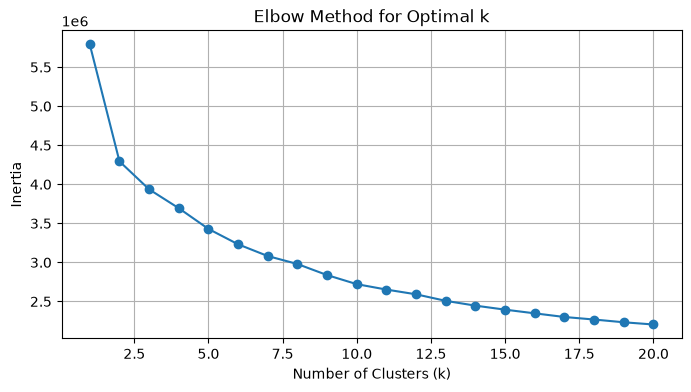

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

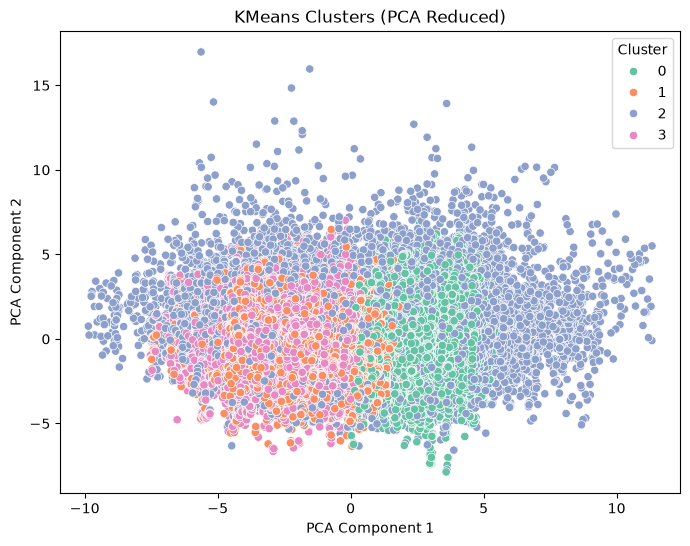

In [35]:
k_optimal = 4
# Upgrade to Gaussian Mixture Model (GMM) to capture probabilistic regime assignments
gmm = GaussianMixture(n_components=k_optimal, covariance_type='diag', random_state=42)
clusters = gmm.fit_predict(scaled_data)
probs = gmm.predict_proba(scaled_data)
df_clean['cluster'] = clusters

In [36]:
# Time-Series Cross-Validation (TSCV) for model stability check
from sklearn.model_selection import TimeSeriesSplit

print('Running 5-fold Time-Series Cross-Validation...')
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(scaled_data)):
    X_train_fold, X_test_fold = scaled_data[train_idx], scaled_data[test_idx]
    
    # Fit model on training fold only to prevent forward data leakage
    gmm_fold = GaussianMixture(n_components=k_optimal, covariance_type='diag', random_state=42)
    gmm_fold.fit(X_train_fold)
    
    train_score = gmm_fold.score(X_train_fold)
    test_score = gmm_fold.score(X_test_fold)
    
    print(f'Fold {fold}: Train Log-Likelihood: {train_score:.4f} | Test Log-Likelihood: {test_score:.4f}')

Running 5-fold Time-Series Cross-Validation...
Fold 0: Train Log-Likelihood: 2.6179 | Test Log-Likelihood: 2.6205
Fold 1: Train Log-Likelihood: 2.6683 | Test Log-Likelihood: 3.0720
Fold 2: Train Log-Likelihood: 3.1596 | Test Log-Likelihood: 4.1995
Fold 3: Train Log-Likelihood: 3.4715 | Test Log-Likelihood: 3.2086
Fold 4: Train Log-Likelihood: 3.3959 | Test Log-Likelihood: 3.4919


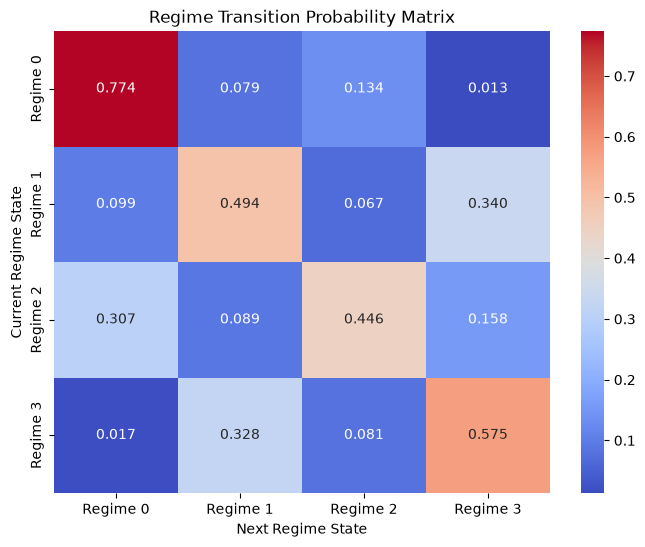

In [37]:
# Regime Transition Probability Matrix calculation & visualization
import numpy as np

def compute_transition_matrix(states, n_components=4):
    matrix = np.zeros((n_components, n_components))
    for t in range(len(states) - 1):
        s_current = states[t]
        s_next = states[t + 1]
        matrix[s_current, s_next] += 1
    
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)
    return matrix

# Compute and plot transition matrix for GMM predicted states
transition_matrix = compute_transition_matrix(clusters, n_components=k_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.3f', 
    xticklabels=[f'Regime {i}' for i in range(k_optimal)],
    yticklabels=[f'Regime {i}' for i in range(k_optimal)]
)
plt.title('Regime Transition Probability Matrix')
plt.ylabel('Current Regime State')
plt.xlabel('Next Regime State')
plt.show()

In [38]:
# Vectorized Backtesting & Financial Valuation (Sharpe, Calmar, Max Drawdown)
import numpy as np

# Map GMM clusters to trading signals based on regime characteristics:
# Assume clusters 0 and 2 are Bullish regimes (Long = 1)
# and clusters 1 and 3 are Bearish regimes (Short = -1)
df_clean['signal'] = np.where((df_clean['cluster'] == 0) | (df_clean['cluster'] == 2), 1, -1)

# Compute strategy log returns (shifting signal by 1 period to prevent look-ahead bias)
df_clean['returns'] = features['log_return'].loc[df_clean.index]
df_clean['strategy_returns'] = df_clean['signal'].shift(1) * df_clean['returns']

# Annualization factor: 1-second intervals in a 6.5 hour trading day, 252 days/year
annual_factor = 252 * 6.5 * 3600
cum_returns = df_clean['strategy_returns'].cumsum().apply(np.exp)

# Compute Sharpe Ratio
mean_ret = df_clean['strategy_returns'].mean()
std_ret = df_clean['strategy_returns'].std()
sharpe = (mean_ret / (std_ret + 1e-9)) * np.sqrt(annual_factor)

# Compute Maximum Drawdown
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak
max_dd = drawdown.min()

# Compute Calmar Ratio
calmar = (mean_ret * annual_factor) / (abs(max_dd) + 1e-9)

print('Backtest Metrics:')
print(f'  Annualized Sharpe Ratio: {sharpe:.4f}')
print(f'  Maximum Drawdown: {max_dd * 100:.2f}%')
print(f'  Calmar Ratio: {calmar:.4f}')

# Plot cumulative strategy returns
plt.figure(figsize=(10, 6))
plt.plot(cum_returns, label='Regime-Based Strategy')
plt.title('Vectorized Backtest: Cumulative Strategy Returns')
plt.xlabel('Time')
plt.ylabel('Cumulative Performance (Base 1.0)')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'cluster'

In [ ]:
# MLflow MLOps Experiment Tracking
import mlflow

# Set the experiment name
mlflow.set_experiment('RegimeRadar_GMM_Clustering')

with mlflow.start_run(run_name='GMM_Microstructure_Regimes'):
    # Log parameters
    mlflow.log_param('num_components', k_optimal)
    mlflow.log_param('covariance_type', 'diag')
    mlflow.log_param('rolling_scaling_lookback', lookback)
    mlflow.log_param('feature_count', len(clustering_features))
    
    # Log financial and model metrics
    mlflow.log_metric('annualized_sharpe_ratio', sharpe)
    mlflow.log_metric('max_drawdown', max_dd)
    mlflow.log_metric('calmar_ratio', calmar)
    
    # Log cluster sizes as metrics
    counts = df_clean['cluster'].value_counts()
    for label, count in counts.items():
        mlflow.log_metric(f'cluster_{label}_size', count)
        
    print('Successfully logged parameters and metrics to MLflow!')
    print(f'Experiment Name: RegimeRadar_GMM_Clustering')
    print(f'Active Run ID: {mlflow.active_run().info.run_id}')

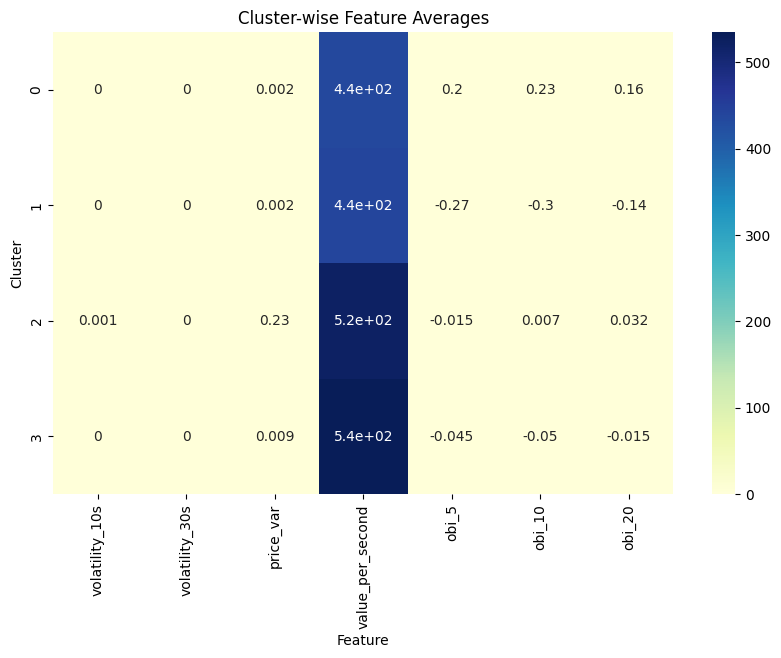

In [ ]:
df_clean['cluster'] = clusters
interpret_features = [
    'volatility_10s', 'volatility_30s',
    'price_var', 'value_per_second',
    'weighted_obi_5', 'weighted_obi_10', 'weighted_obi_20',
    'bid_ask_spread', 'micro_price'
]
cluster_averages = df_clean.groupby('cluster')[interpret_features].mean().round(3)
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_averages, annot=True, cmap='YlGnBu')
plt.title("Cluster-wise Feature Averages")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.show()

In [ ]:
df_clean['cluster'] = clusters
cluster_summary = df_clean.groupby('cluster')[[
    'volatility_10s', 'volatility_30s',
    'price_var', 'value_per_second',
    'weighted_obi_5', 'weighted_obi_10', 'weighted_obi_20',
    'bid_ask_spread', 'micro_price'
]].mean()
print(cluster_summary)

         volatility_10s  volatility_30s  price_var  value_per_second  \
cluster                                                                
0              0.000067        0.000074   0.002076        435.304202   
1              0.000065        0.000074   0.001913        439.380095   
2              0.000655        0.000449   0.230333        522.041144   
3              0.000138        0.000140   0.008578        535.009489   

            obi_5    obi_10    obi_20  
cluster                                
0        0.199713  0.225489  0.161757  
1       -0.266143 -0.304350 -0.143151  
2       -0.014799  0.006838  0.031653  
3       -0.044892 -0.050457 -0.014870  


cluster_label
Stable Bearish                 136901
Stable Bullish                 126539
Moderate Volatility Bearish     81922
High Volatility Bullish           204
Name: count, dtype: int64


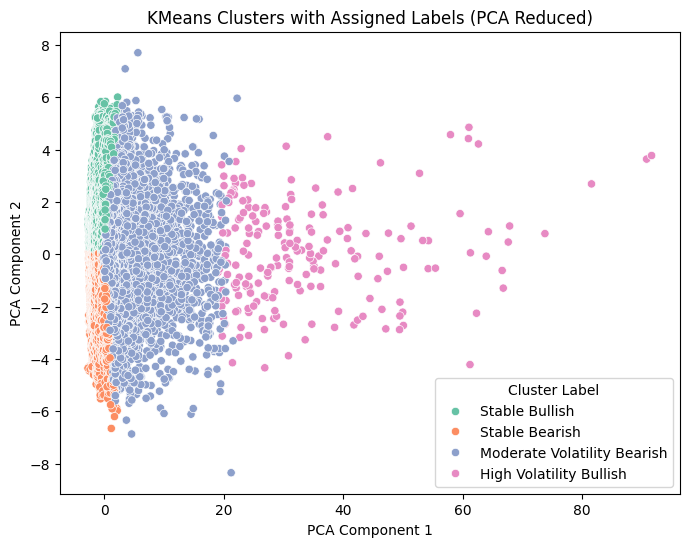

In [ ]:
cluster_labels = {
    0: "Stable Bullish",
    1: "Stable Bearish",
    2: "High Volatility Bullish",
    3: "Moderate Volatility Bearish"
}

df_clean['cluster'] = clusters
df_clean['cluster_label'] = df_clean['cluster'].map(cluster_labels)

print(df_clean['cluster_label'].value_counts())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df_clean['cluster_label'], palette='Set2')
plt.title("KMeans Clusters with Assigned Labels (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster Label")
plt.show()
